In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from lifelines import KaplanMeierFitter
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(palette='pastel')

plt.rc('font', family='Malgun Gothic')

plt.rc('axes', unicode_minus=False)
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 50)
# 한글 폰트 출력
import matplotlib.font_manager as fm

# 설치된 폰트 출력
font_list = [font.name for font in fm.fontManager.ttflist]
# font_list

# plt.rcParams['font.family'] = 'Pretendard'



In [3]:
# 데이터 불러오기
merchant_df = pd.read_csv('../data/raw/big_data_set1_f.csv', encoding='cp949')
sale_df = pd.read_csv('../data/raw/big_data_set2_f.csv', encoding='cp949')
cust_df = pd.read_csv('../data/raw/big_data_set3_f.csv', encoding='cp949')
con_pric_df = pd.read_csv('../data/raw/소비자물가지수.csv')

In [4]:
# merchant_df 컬럼명 변경
merchant_df.columns = ['mct_id', 'mct_address', 'mct_name', 'brand_code', 'sigungu', 'industry_name', 'commercial_area', 'open_date', 'close_date']

In [5]:
# sale_df 컬럼명 변경
sale_df.columns = ['mct_id', 'trans_date', 'operation_band', 'sale_amt_band', 'sale_cnt_band', 'unique_customer_band', 'aov_band', 'cancel_rate_band', 'delivery_sale_amount_ratio', 'industry_sale_amt_ratio', 'industry_sale_cnt_ratio',
                   'industry_sale_rank_pct', 'area_sale_rank_pct', 'industry_close_pct', 'area_close_pct']

In [6]:
# cust_df 컬럼명 변경
cust_df.columns = ['mct_id', 'trans_date', 'male_u20', 'male_u30', 'male_u40', 'male_u50', 'male_u60', 'female_u20', 'female_u30', 'female_u40', 'female_u50', 'female_u60', 
                   'visit_re', 'visit_new', 'route_resident', 'route_worker', 'route_floating']

In [7]:
## 구간 데이터 전처리
# 복사본 생성
sale_df_prc = sale_df.copy()

# 구간 데이터 앞에 숫자만 빼오기
sale_df_prc.loc[:, 'operation_band':'cancel_rate_band'] = sale_df_prc.loc[:, 'operation_band':'cancel_rate_band'].apply(lambda x: x.str.split('_', expand=True)[0])

# 결측치 최빈값으로 대체 후 구간 데이터들의 자료형 int형으로 변환
# 가정: 결측값의 경우 취소율이 적다고 판단!!
band_cols = sale_df_prc.loc[:, 'operation_band':'cancel_rate_band'].columns
sale_df_prc[band_cols] = sale_df_prc[band_cols].fillna(1).astype(int)

## 비율 데이터 전처리
# 배달매출금액 비율의 -999999.9는 배달매출 미존재 의미 => 0으로 대체 가능 (배달매출금액 비율이 처음부터 0인 데이터도 있긴 함)
sale_df_prc['delivery_sale_amount_ratio'] = sale_df_prc['delivery_sale_amount_ratio'].map(lambda x: 0 if x < 0 else x)

# 동일 상권 내 해지 가맹점 비중의 -999999.9는 상권 미존재 의미 => 100으로 할 수 도 있겠으나 일단 0으로 대체
sale_df_prc['area_close_pct'] = sale_df_prc['area_close_pct'].map(lambda x: 0 if x < 0 else x)

# 가맹점별 매출정보 평균계산
sale_df_prc = sale_df_prc.drop('trans_date', axis=1).groupby('mct_id').mean().reset_index()

# sale_df_prc 데이터와 merchant_df 결합한 데이터 merged_df에 저장
merged_df = merchant_df.merge(sale_df_prc, on='mct_id')

In [8]:
## 고객 데이터 전처리
# 복사본 생성
cust_df_prc = cust_df.copy()

# 결측치는 0으로 대체
cust_cols = cust_df_prc.iloc[:, 2:].columns
cust_df_prc[cust_cols] = cust_df_prc[cust_cols].clip(lower=0)

#  가맹점별 고객정보 평균계산
cust_df_prc = cust_df_prc.drop('trans_date', axis=1).groupby('mct_id').mean().reset_index()

# cust_df_prc 데이터 merged_df에 추가
merged_df = merged_df.merge(cust_df_prc, on='mct_id')

In [9]:
## 업종 그룹화 
meat = ['한식-육류/고기',  '꼬치구이']
cafe = ['카페',  '주스',  '차',  '테마카페',  '커피전문점', '테이크아웃커피',  '구내식당/푸드코트']
k_food = ['백반/가정식',  '기사식당', '한식-두부요리', '한식-단품요리일반',  '한정식',    '한식-죽',  '한식-국수/만두',  '한식-국밥/설렁탕',  '한식-찌개/전골',  '한식-냉면',  '한식뷔페',  '한식-감자탕',   '한식-해물/생선']
w_food = ['양식',  '스테이크', '치킨',  '햄버거',  '피자']
j_food = ['일식당',  '일식-우동/소바/라면',  '일식-초밥/롤',  '일식-덮밥/돈가스',  '일식-샤브샤브',  '일식-참치회']
c_food = ['중식당',  '중식-딤섬/중식만두',  '중식-훠궈/마라탕']
drink = ['호프/맥주',  '요리주점',  '민속주점',  '포장마차',  '이자카야',  '와인바', '주류',  '와인샵']
product= ['농산물',  '청과물',  '수산물',  '건어물',  '축산물']
enter = ['일반 유흥주점',  '룸살롱/단란주점']
convenience = ['샌드위치/토스트',  '도시락', '분식']
world_food = ['동남아/인도음식',  '기타세계요리']
dessert = ['도너츠',  '탕후루',  '와플/크로플',  '마카롱',  '아이스크림/빙수',  '떡/한과',  '떡/한과 제조',  '베이커리']
others = ['식품 제조',  '반찬',  '미곡상',  '유제품',  '인삼제품', '건강식품',  '건강원', '담배',  '식료품']

# replace 진행
groups_to_replace = [(meat, 'meat'), (cafe, 'cafe'), (k_food, 'k_food'), (w_food, 'w_food'), (j_food, 'j_food'),
                                       (c_food, 'c_food'), (drink, 'drink'), (product, 'product'), (enter, 'enter'), (convenience, 'convenience'),
                                       (world_food, 'world_food'), (dessert, 'dessert'), (others, 'others')]
replacement = {}
for ind, cat in groups_to_replace:
    for i in ind:
        replacement[i] = cat

merged_df['industry_name'].replace(replacement, inplace=True)

In [10]:
# 상권 데이터 1개만 존재하는 경우 주변 상권과 통합 (장한평자동차와 답십리는 모두 구석진 곳인데 가까우므로 결합)
areas_to_replace = {'화양시장': '성수', '자양': '성수', '서면역': '성수', '미아사거리': '성수',
                                    '방배역': '뚝섬', '건대입구': '뚝섬', '풍산지구': '뚝섬', '오남': '한양대',
                                    '동대문역사문화공원역': '금남시장',  '압구정로데오': '금남시장',  '장한평자동차': '답십리'}
merged_df['commercial_area'].replace(areas_to_replace, inplace=True)

# 상권 결측치는 Unknown으로 대체
merged_df['commercial_area'].fillna('Unknown', inplace=True)

In [11]:
# 폐업여부 나타내는 is_closed 컬럼 추가
merged_df['is_closed'] = merged_df['close_date'].notna().astype(int)

In [12]:
# 기존 merchant_df에 존재했던 컬럼 중 모델에 사용할 수 없는 컬럼 제거
merged_df.drop(['mct_id', 'mct_address', 'mct_name', 'brand_code', 'sigungu', 'open_date', 'close_date'], axis=1, inplace=True)

In [13]:
# 상관계수 절댓값이 0.7 이상인 컬럼들이 있으면 둘 중 하나 제거
merged_df.drop(['sale_amt_band', 'unique_customer_band', 'industry_sale_cnt_ratio', 'industry_sale_rank_pct'], axis=1, inplace=True)

In [14]:
#====================================================================================

In [15]:
cust_df = cust_df.drop(['trans_date'],axis = 1)

In [16]:
merged_df = pd.merge(
    sale_df,
    cust_df,
    on="mct_id",       
    how="outer",         
)

merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1960290 entries, 0 to 1960289
Data columns (total 30 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   mct_id                      object 
 1   trans_date                  int64  
 2   operation_band              object 
 3   sale_amt_band               object 
 4   sale_cnt_band               object 
 5   unique_customer_band        object 
 6   aov_band                    object 
 7   cancel_rate_band            object 
 8   delivery_sale_amount_ratio  float64
 9   industry_sale_amt_ratio     float64
 10  industry_sale_cnt_ratio     float64
 11  industry_sale_rank_pct      float64
 12  area_sale_rank_pct          float64
 13  industry_close_pct          float64
 14  area_close_pct              float64
 15  male_u20                    float64
 16  male_u30                    float64
 17  male_u40                    float64
 18  male_u50                    float64
 19  male_u60             

In [17]:
merged_df['trans_date']

0          202404
1          202404
2          202404
3          202404
4          202404
            ...  
1960285    202412
1960286    202412
1960287    202412
1960288    202412
1960289    202412
Name: trans_date, Length: 1960290, dtype: int64

In [18]:
merchant_df["brand_code"].notnull().astype(int)

0       0
1       0
2       0
3       0
4       0
       ..
4180    0
4181    0
4182    0
4183    1
4184    0
Name: brand_code, Length: 4185, dtype: int64

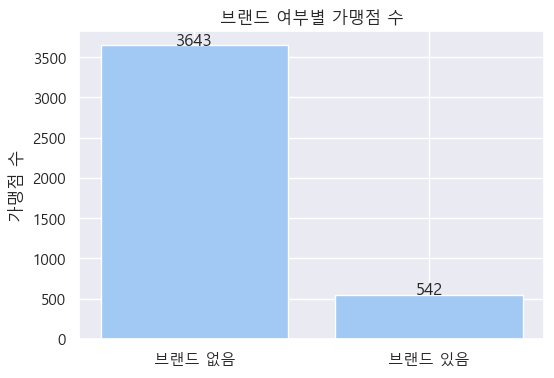

In [19]:
merchant_df["brand_code"] = merchant_df["brand_code"].notnull().astype(int)

counts = merchant_df["brand_code"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["브랜드 없음", "브랜드 있음"], counts)
plt.title("브랜드 여부별 가맹점 수")
plt.ylabel("가맹점 수")

for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha="center")

plt.show()


In [20]:
merchant_df.head()

,mct_id,mct_address,mct_name,brand_code,sigungu,industry_name,commercial_area,open_date,close_date
0,16184E93D9,서울 성동구 마장동,성우**,0,서울 성동구,축산물,마장동,20130320,NaN
1,4D039EA8B7,서울 성동구 마장동,대보**,0,서울 성동구,축산물,마장동,20131122,NaN
2,0074C4990A,서울 성동구 마장동,대용**,0,서울 성동구,축산물,마장동,20140512,NaN
3,68308F2746,서울 성동구 마장동,통일**,0,서울 성동구,축산물,마장동,20151124,NaN
4,4117EDDE9C,서울 성동구 마장동,한울**,0,서울 성동구,축산물,마장동,20151211,NaN


In [21]:
merged_df.head()

,mct_id,trans_date,operation_band,sale_amt_band,sale_cnt_band,unique_customer_band,aov_band,cancel_rate_band,delivery_sale_amount_ratio,industry_sale_amt_ratio,industry_sale_cnt_ratio,industry_sale_rank_pct,area_sale_rank_pct,industry_close_pct,area_close_pct,male_u20,male_u30,male_u40,male_u50,male_u60,female_u20,female_u30,female_u40,female_u50,female_u60,visit_re,visit_new,route_resident,route_worker,route_floating
0,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8,0.0000,45.600,0.0000,30.4000,0.000,0.0000,14.400,0.0000,9.6000,0.000,0.00,20.00,0.0,0.0,100.0
1,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8,0.0000,36.000,0.0000,36.0000,0.000,0.0000,14.000,0.0000,14.0000,0.000,0.00,50.00,0.0,100.0,0.0
2,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8,12.5083,37.450,0.0000,24.9417,0.000,4.1917,12.550,0.0000,8.3583,0.000,0.00,16.67,0.0,0.0,100.0
3,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8,11.6250,7.254,5.8125,13.0665,8.742,13.3750,8.346,6.6875,15.0335,10.058,8.11,5.41,50.0,0.0,50.0
4,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8,0.0000,45.600,0.0000,30.4000,0.000,0.0000,14.400,0.0000,9.6000,0.000,0.00,0.00,-999999.9,-999999.9,-999999.9


In [22]:
industry_counts = merchant_df['industry_name'].value_counts().reset_index()
industry_counts.columns = ['업종', '개수']
print(industry_counts.head(30))


           업종   개수
0    한식-육류/고기  442
1          카페  357
2      백반/가정식  346
3   한식-단품요리일반  306
4         축산물  285
5       커피전문점  182
6          양식  176
7         식료품  158
8        베이커리  146
9          분식  140
10         치킨  139
11        일식당  135
12   한식-해물/생선  121
13        중식당   99
14      호프/맥주   84
15       요리주점   80
16   한식-국수/만두   64
17   아이스크림/빙수   61
18  한식-국밥/설렁탕   60
19        농산물   59
20         피자   51
21   한식-찌개/전골   48
22    일반 유흥주점   45
23       포장마차   42
24       이자카야   37
25   샌드위치/토스트   35
26  일식-덮밥/돈가스   34
27   동남아/인도음식   32
28        햄버거   31
29        와인바   30


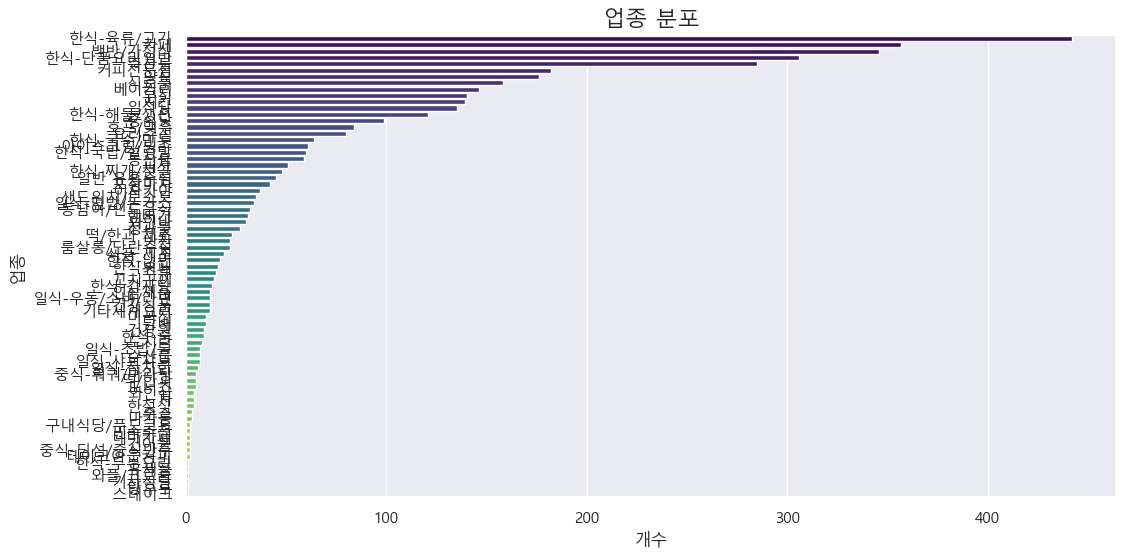

In [23]:
plt.figure(figsize=(12,6))
sns.barplot(data=industry_counts, x='개수', y='업종', palette="viridis")

plt.title("업종 분포", fontsize=16)
plt.xlabel("개수")
plt.ylabel("업종")
plt.show()


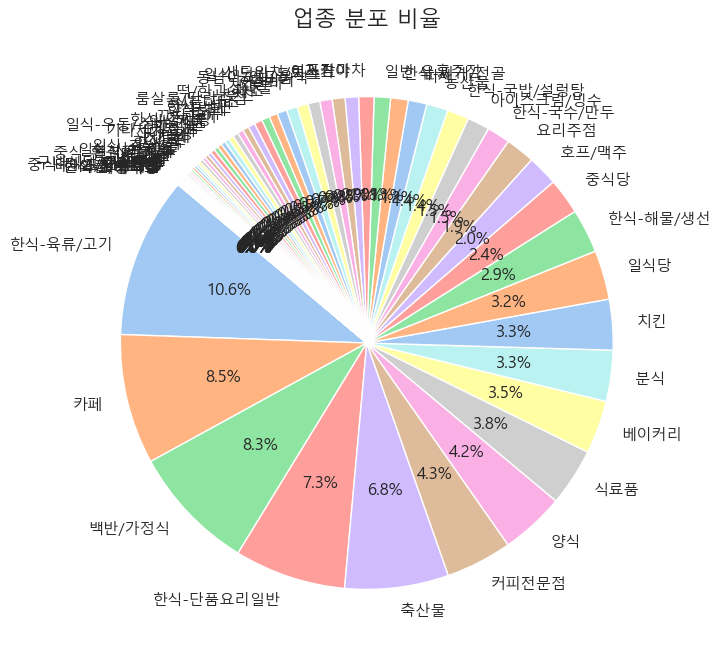

In [24]:
plt.figure(figsize=(8,8))
plt.pie(industry_counts['개수'], labels=industry_counts['업종'], autopct='%1.1f%%', startangle=140)
plt.title("업종 분포 비율", fontsize=16)
plt.show()


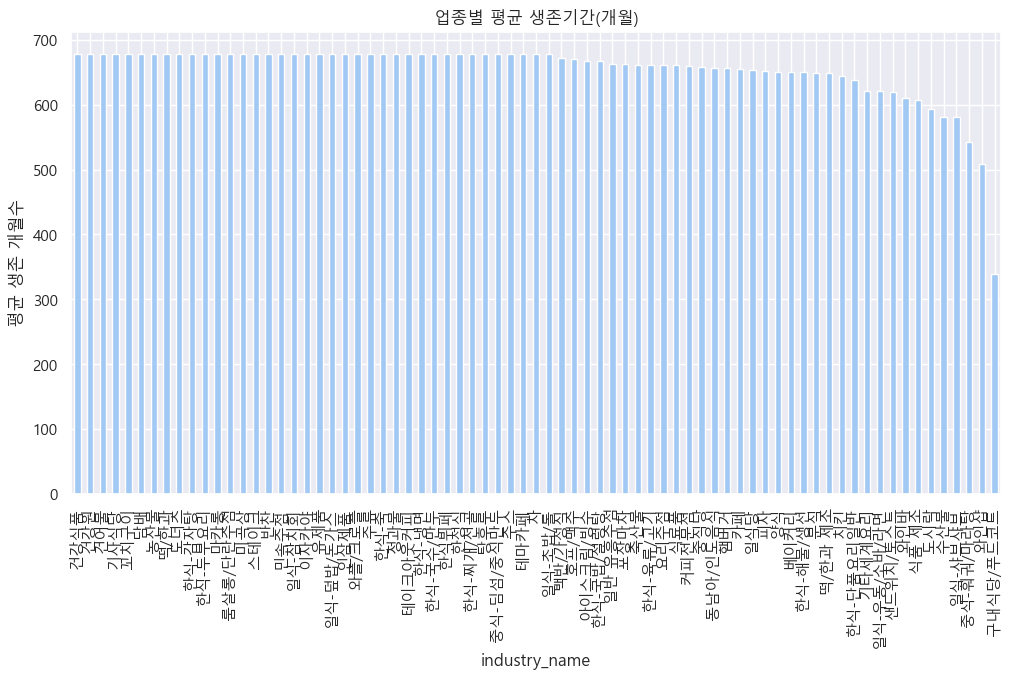

In [25]:
merchant_df['open_date'] = pd.to_datetime(merchant_df['open_date'], errors='coerce')
merchant_df['close_date'] = pd.to_datetime(merchant_df['close_date'], errors='coerce')

reference_date = pd.to_datetime("today")
merchant_df['생존개월수'] = ((merchant_df['close_date'].fillna(reference_date) - merchant_df['open_date'])/pd.Timedelta(days=30)).astype(int)

industry_life = merchant_df.groupby('industry_name')['생존개월수'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
industry_life.plot(kind='bar')
plt.title("업종별 평균 생존기간(개월)")
plt.ylabel("평균 생존 개월수")
plt.show()


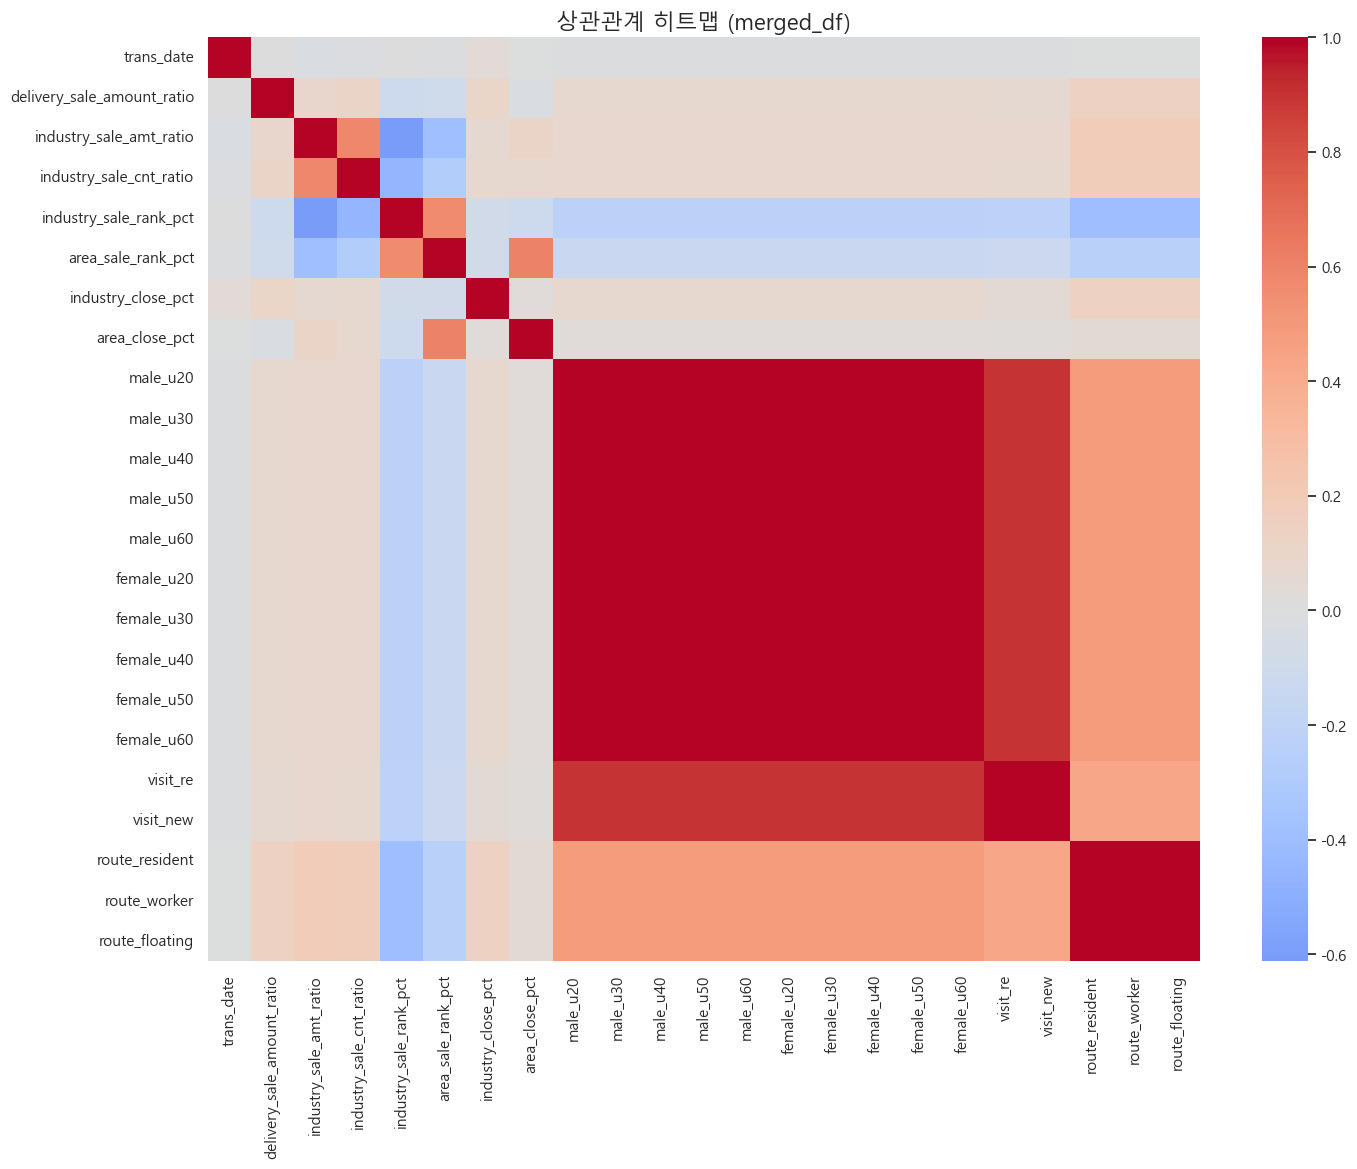

In [26]:
numeric_df = merged_df.select_dtypes(include=["int64", "float64"])

corr = numeric_df.corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("상관관계 히트맵 (merged_df)", fontsize=16)
plt.show()


In [27]:
merged_df.sort_values(by="trans_date").reset_index(drop=True)

,mct_id,trans_date,operation_band,sale_amt_band,sale_cnt_band,unique_customer_band,aov_band,cancel_rate_band,delivery_sale_amount_ratio,industry_sale_amt_ratio,industry_sale_cnt_ratio,industry_sale_rank_pct,area_sale_rank_pct,industry_close_pct,area_close_pct,male_u20,male_u30,male_u40,male_u50,male_u60,female_u20,female_u30,female_u40,female_u50,female_u60,visit_re,visit_new,route_resident,route_worker,route_floating
0,4BF6B1EEF7,202301,4_50-75%,4_50-75%,4_50-75%,4_50-75%,3_25-50%,1_상위1구간,0.0,63.5,78.8,30.3,0.0,6.6,-999999.9,6.1398,17.0550,24.4834,19.1016,9.0960,1.9602,5.4450,7.8166,6.0984,2.9040,8.04,9.65,35.9,10.3,53.8
1,4BF6B1EEF7,202301,4_50-75%,4_50-75%,4_50-75%,4_50-75%,3_25-50%,1_상위1구간,0.0,63.5,78.8,30.3,0.0,6.6,-999999.9,7.1586,16.6788,24.2064,18.4500,7.3800,2.5414,5.9212,8.5936,6.5500,2.6200,10.00,8.11,42.4,12.1,45.5
2,4BF6B1EEF7,202301,4_50-75%,4_50-75%,4_50-75%,4_50-75%,3_25-50%,1_상위1구간,0.0,63.5,78.8,30.3,0.0,6.6,-999999.9,6.5059,15.2048,22.2955,19.7370,9.2837,2.3941,5.5952,8.2045,7.2630,3.4163,9.51,6.63,21.4,17.9,60.7
3,9DBBC0BC17,202301,4_50-75%,4_50-75%,3_25-50%,3_25-50%,5_75-90%,1_상위1구간,-999999.9,40.5,160.3,44.4,41.7,14.8,8.7,2.6164,11.2674,18.9900,5.1906,4.1356,3.5836,15.4326,26.0100,7.1094,5.6644,51.93,6.82,64.6,1.5,33.8
4,9DBBC0BC17,202301,4_50-75%,4_50-75%,3_25-50%,3_25-50%,5_75-90%,1_상위1구간,-999999.9,40.5,160.3,44.4,41.7,14.8,8.7,2.2860,10.3251,16.9545,4.4577,4.0767,3.7140,16.7749,27.5455,7.2423,6.6233,51.52,4.24,62.8,2.3,34.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1960285,000F03E44A,202412,4_50-75%,6_90%초과(하위 10% 이하),5_75-90%,5_75-90%,5_75-90%,1_상위1구간,78.0,0.7,4.1,86.8,62.8,17.4,9.0,0.0000,45.6000,0.0000,30.4000,0.0000,0.0000,14.4000,0.0000,9.6000,0.0000,0.00,0.00,-999999.9,-999999.9,-999999.9
1960286,000F03E44A,202412,4_50-75%,6_90%초과(하위 10% 이하),5_75-90%,5_75-90%,5_75-90%,1_상위1구간,78.0,0.7,4.1,86.8,62.8,17.4,9.0,11.6250,7.2540,5.8125,13.0665,8.7420,13.3750,8.3460,6.6875,15.0335,10.0580,8.11,5.41,50.0,0.0,50.0
1960287,000F03E44A,202412,4_50-75%,6_90%초과(하위 10% 이하),5_75-90%,5_75-90%,5_75-90%,1_상위1구간,78.0,0.7,4.1,86.8,62.8,17.4,9.0,12.5083,37.4500,0.0000,24.9417,0.0000,4.1917,12.5500,0.0000,8.3583,0.0000,0.00,16.67,0.0,0.0,100.0
1960288,000F03E44A,202412,4_50-75%,6_90%초과(하위 10% 이하),5_75-90%,5_75-90%,5_75-90%,1_상위1구간,78.0,0.7,4.1,86.8,62.8,17.4,9.0,0.0000,36.0000,0.0000,36.0000,0.0000,0.0000,14.0000,0.0000,14.0000,0.0000,0.00,50.00,0.0,100.0,0.0


In [28]:
from sklearn.preprocessing import MinMaxScaler

mapping = {
    "1_10%이하": 0.05,
    "2_10-25%": 0.175,
    "3_25-50%": 0.375,
    "4_50-75%": 0.625,
    "5_75-90%": 0.825,
    "6_90%초과(하위 10% 이하)": 0.95
}

merged_df["매출값"] = merged_df["sale_amt_band"].map(mapping)

merged_df["trans_month"] = pd.to_datetime(
    merged_df["trans_date"].astype(str).str.zfill(6),  # 예: 20241 → 202401
    format="%Y%m",
    errors="coerce"
)

df = con_pric_df.set_index("주요품목별(1)")
df_T = df.T
df_T.index = pd.to_datetime(df_T.index, format="%Y. %m")

df_T["전체평균"] = df_T.mean(axis=1)
cpi = df_T[["전체평균"]]


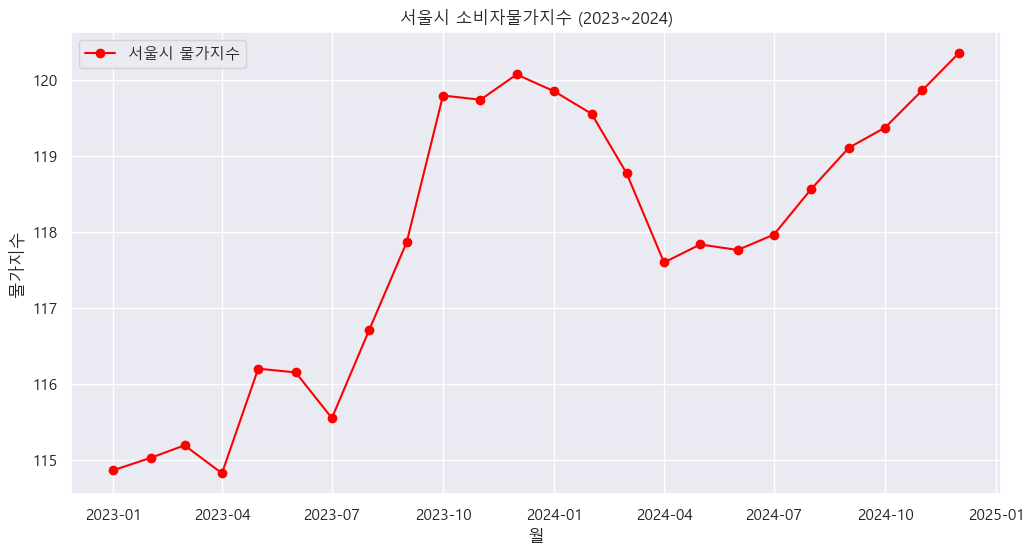

In [29]:
plt.figure(figsize=(12,6))
plt.plot(cpi.index, cpi["전체평균"], marker="o", color="red", label="서울시 물가지수")

plt.title("서울시 소비자물가지수 (2023~2024)")
plt.xlabel("월")
plt.ylabel("물가지수")
plt.legend()
plt.grid(True)
plt.show()


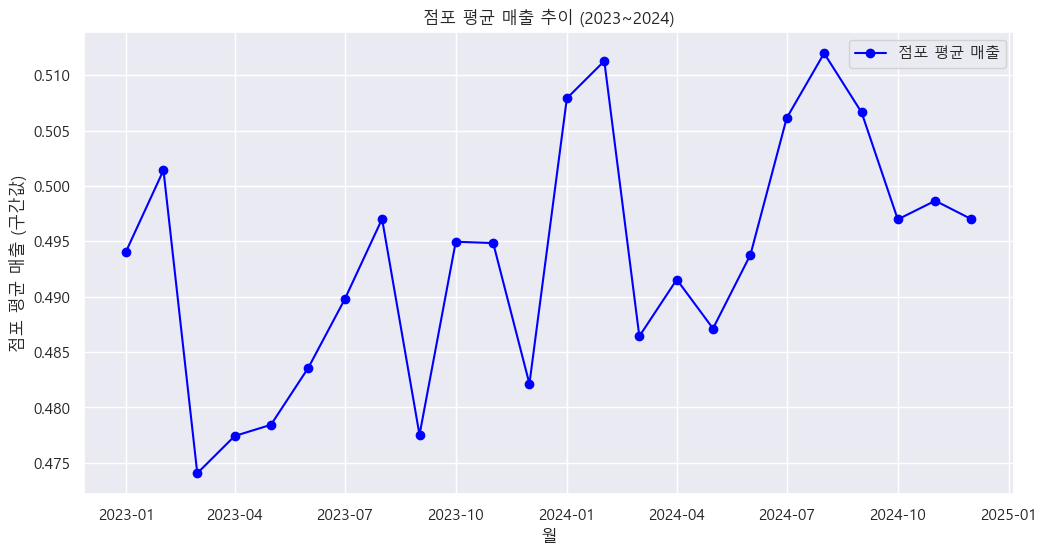

In [30]:
sales_sum = merged_df.groupby(merged_df["trans_month"].dt.to_period("M"))["매출값"].sum()
sales_cnt = merged_df.groupby(merged_df["trans_month"].dt.to_period("M"))["매출값"].count()
sales = (sales_sum / sales_cnt).to_timestamp().to_frame(name="점포평균매출")

plt.figure(figsize=(12,6))
plt.plot(sales.index, sales["점포평균매출"], marker="o", color="blue", label="점포 평균 매출")

plt.title("점포 평균 매출 추이 (2023~2024)")
plt.xlabel("월")
plt.ylabel("점포 평균 매출 (구간값)")
plt.legend()
plt.grid(True)
plt.show()


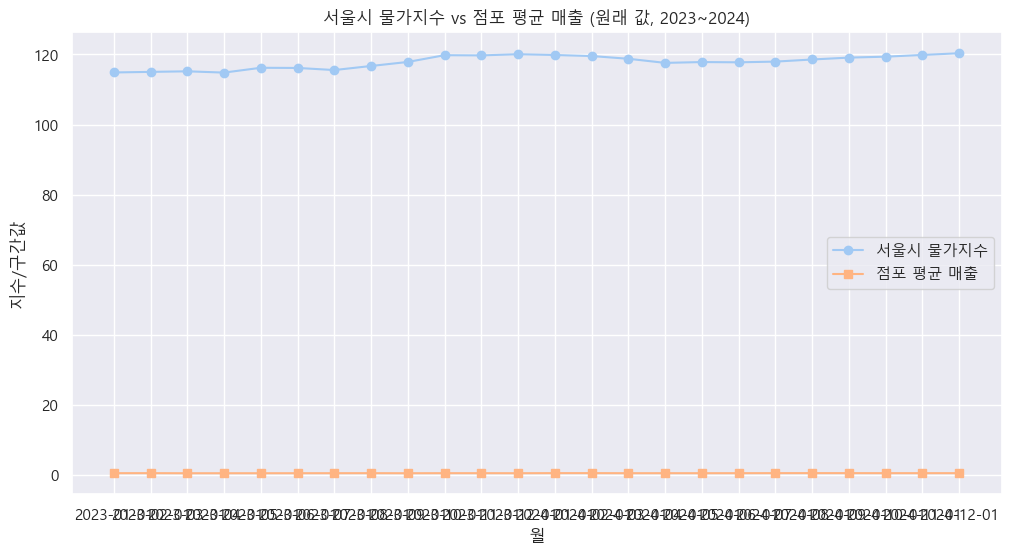

In [31]:
merged = pd.concat([cpi, sales], axis=1).dropna()

plt.figure(figsize=(12,6))
plt.plot(merged.index.astype(str), merged["전체평균"], marker="o", label="서울시 물가지수")
plt.plot(merged.index.astype(str), merged["점포평균매출"], marker="s", label="점포 평균 매출")

plt.title("서울시 물가지수 vs 점포 평균 매출 (원래 값, 2023~2024)")
plt.xlabel("월")
plt.ylabel("지수/구간값")
plt.legend()
plt.grid(True)
plt.show()


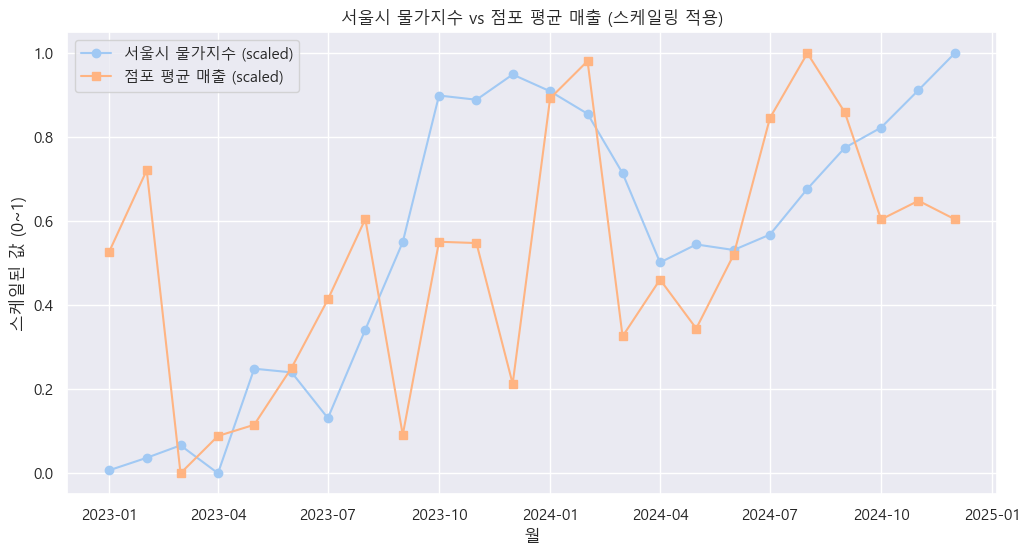

In [32]:
scaler = MinMaxScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(merged),
    index=merged.index,
    columns=merged.columns
)

# 시각화
plt.figure(figsize=(12,6))
plt.plot(scaled.index, scaled["전체평균"], marker="o", label="서울시 물가지수 (scaled)")
plt.plot(scaled.index, scaled["점포평균매출"], marker="s", label="점포 평균 매출 (scaled)")

plt.title("서울시 물가지수 vs 점포 평균 매출 (스케일링 적용)")
plt.xlabel("월")
plt.ylabel("스케일된 값 (0~1)")
plt.legend()
plt.grid(True)
plt.show()


In [33]:
minimum_wage = {'2023': 9620,'2024': 9860, '2025': 10030}

In [34]:
merged_df["trans_date"] = pd.to_datetime(merged_df["trans_date"], format="%Y%m", errors="coerce")

merged_df["sale_value"] = merged_df["sale_amt_band"].map(mapping)

master = merged_df.merge(
    merchant_df[[
        "mct_id","industry_name","commercial_area","open_date","close_date"
    ]],
    on="mct_id", how="left"
)

master["closed_flag"] = master["close_date"].notnull().astype(int)

master["close_month"] = master["close_date"].dt.to_period("M").dt.to_timestamp()
master["months_from_close"] = (
    (master["trans_date"].dt.year - master["close_month"].dt.year) * 12 +
    (master["trans_date"].dt.month - master["close_month"].dt.month)
)

last_month_per_store = master.groupby("mct_id")["trans_date"].max().rename("last_month")
master = master.merge(last_month_per_store, on="mct_id", how="left")
master["months_from_last"] = (
    (master["trans_date"].dt.year - master["last_month"].dt.year) * 12 +
    (master["trans_date"].dt.month - master["last_month"].dt.month)
)


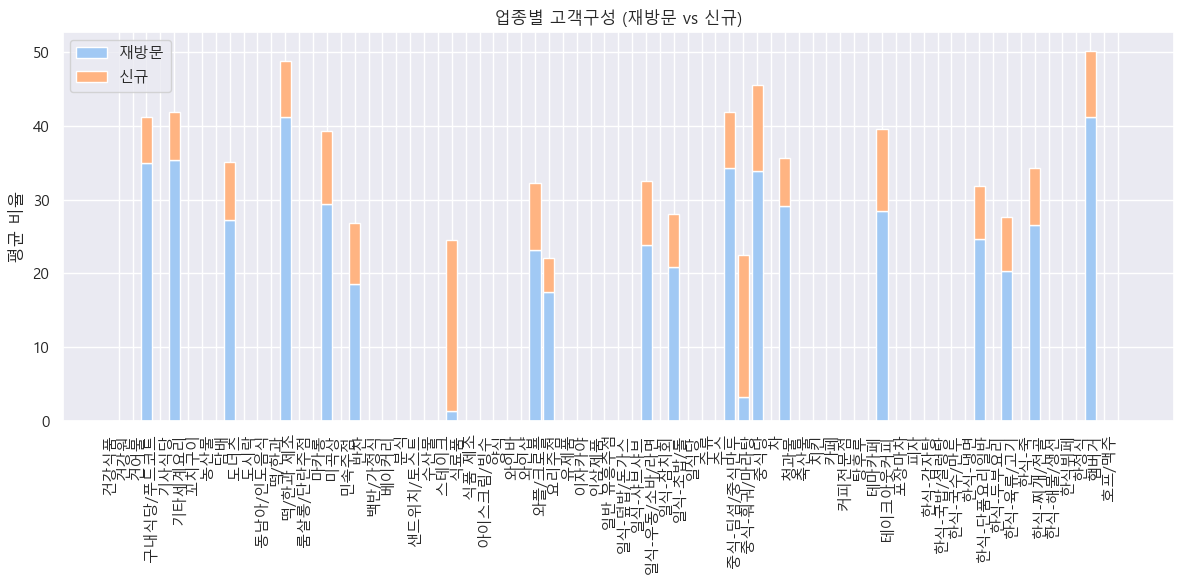

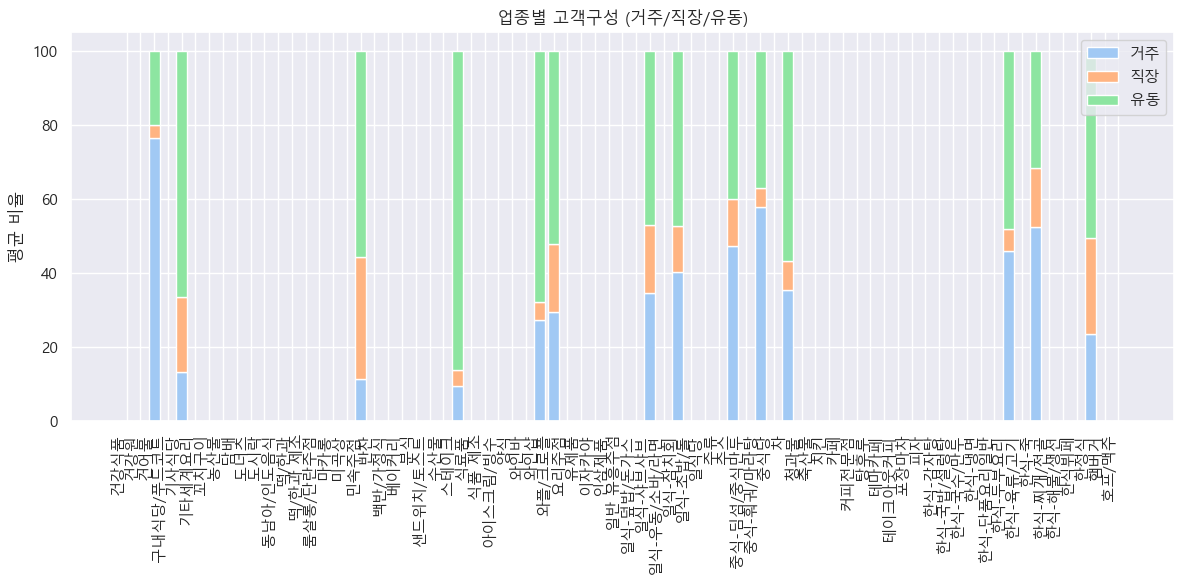

In [46]:
visit_cols = ["visit_re", "visit_new"]
route_cols = ["route_resident", "route_worker", "route_floating"]

use = master.dropna(subset=["industry_name"])
visit_mix = use.groupby("industry_name")[visit_cols].mean().clip(lower=0)
route_mix = use.groupby("industry_name")[route_cols].mean().clip(lower=0)

plt.figure(figsize=(12,6))
bottom = np.zeros(len(visit_mix))
x = np.arange(len(visit_mix))
labels = ["재방문", "신규"]

for i, col in enumerate(visit_cols):
    vals = visit_mix[col].values
    plt.bar(x, vals, bottom=bottom, label=labels[i])
    bottom += vals

plt.xticks(x, visit_mix.index, rotation=90, ha="right")
plt.ylabel("평균 비율")
plt.title("업종별 고객구성 (재방문 vs 신규)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
bottom = np.zeros(len(route_mix))
x = np.arange(len(route_mix))
labels = ["거주", "직장", "유동"]

for i, col in enumerate(route_cols):
    vals = route_mix[col].values
    plt.bar(x, vals, bottom=bottom, label=labels[i])
    bottom += vals

plt.xticks(x, route_mix.index, rotation=90, ha="right")
plt.ylabel("평균 비율")
plt.title("업종별 고객구성 (거주/직장/유동)")
plt.legend()
plt.tight_layout()
plt.show()


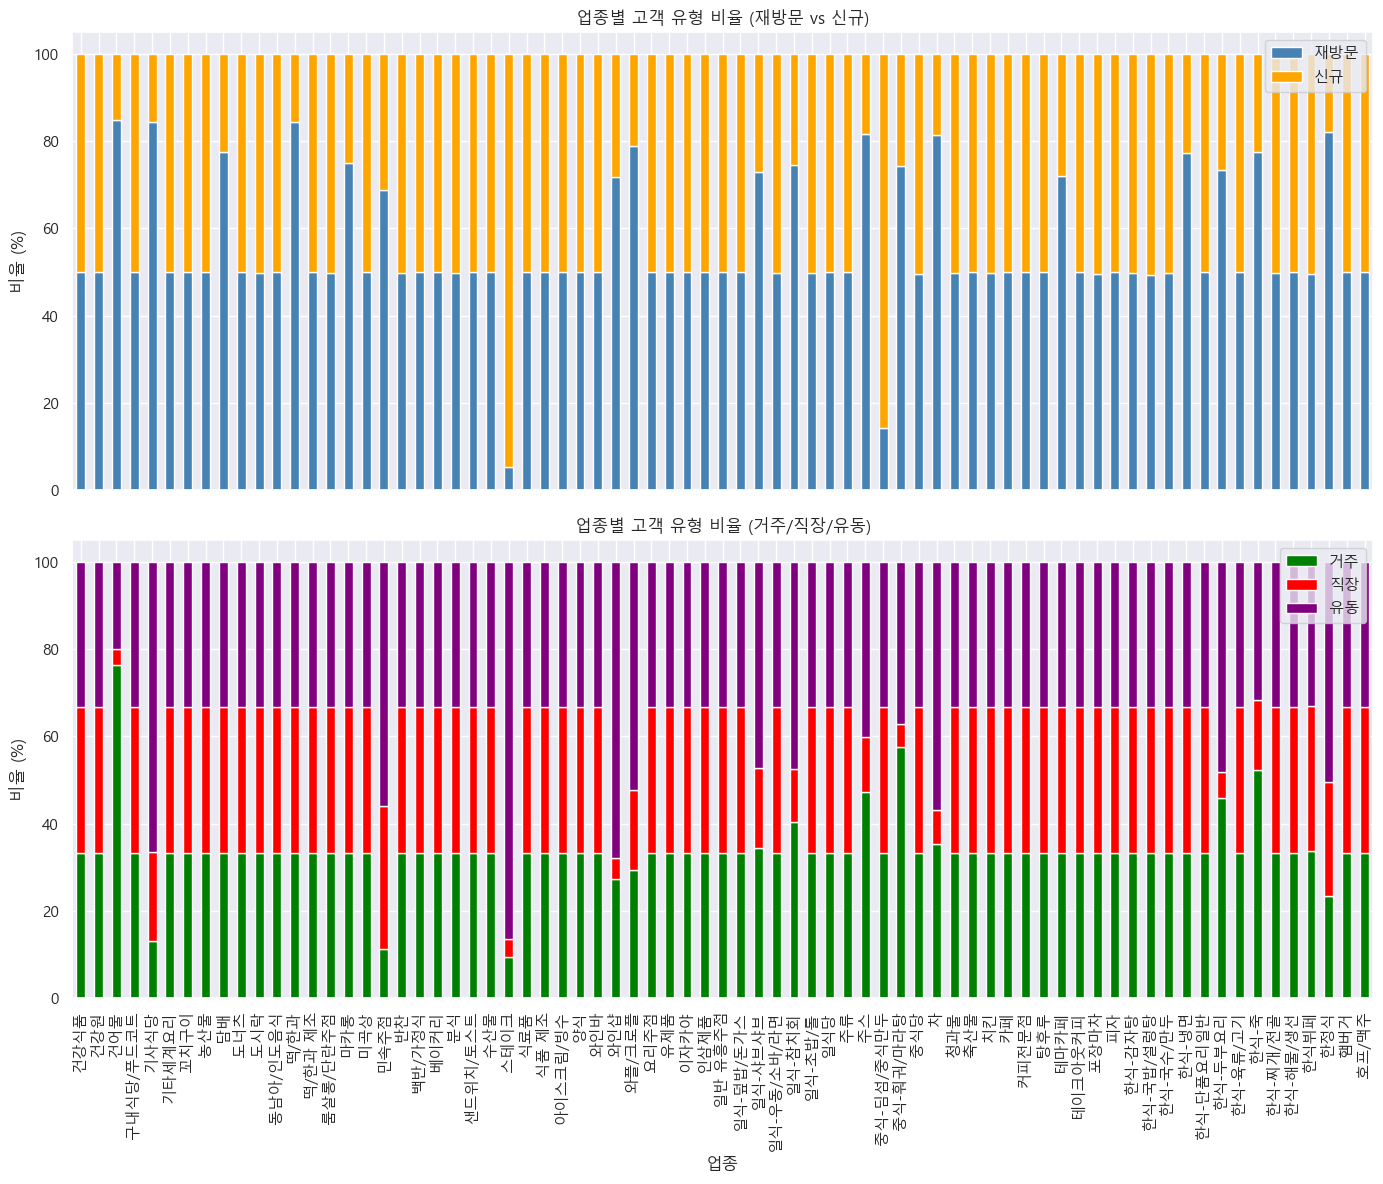

In [47]:
cols = [
    "industry_name",
    "visit_re", "visit_new",
    "route_resident", "route_worker", "route_floating"
]

df_ratio = master[cols].groupby("industry_name").mean()

df_visit = df_ratio[["visit_re", "visit_new"]]
df_visit_pct = df_visit.div(df_visit.sum(axis=1), axis=0) * 100

df_route = df_ratio[["route_resident", "route_worker", "route_floating"]]
df_route_pct = df_route.div(df_route.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(14,12), sharex=True)

df_visit_pct.plot(kind="bar", stacked=True, ax=axes[0],
                  color=["steelblue", "orange"])
axes[0].set_title("업종별 고객 유형 비율 (재방문 vs 신규)")
axes[0].set_ylabel("비율 (%)")
axes[0].set_xlabel("업종")
axes[0].legend(["재방문", "신규"])

df_route_pct.plot(kind="bar", stacked=True, ax=axes[1],
                  color=["green", "red", "purple"])
axes[1].set_title("업종별 고객 유형 비율 (거주/직장/유동)")
axes[1].set_ylabel("비율 (%)")
axes[1].set_xlabel("업종")
axes[1].legend(["거주", "직장", "유동"])

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


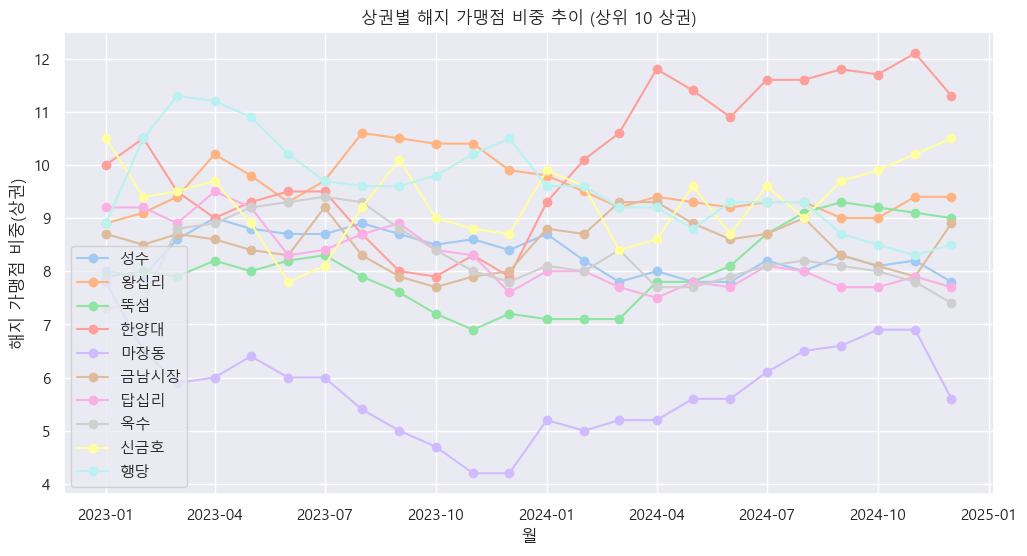

In [37]:
N = 10  

cnt_by_area = master.groupby("commercial_area")["mct_id"].nunique().sort_values(ascending=False)
top_area = cnt_by_area.head(N).index.tolist()

trend = (
    master[master["commercial_area"].isin(top_area)]
    .groupby(["trans_date","commercial_area"])["area_close_pct"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))
for area in top_area:
    s = trend[trend["commercial_area"]==area]
    plt.plot(s["trans_date"], s["area_close_pct"], marker="o", label=area)

plt.title(f"상권별 해지 가맹점 비중 추이 (상위 {N} 상권)")
plt.xlabel("월")
plt.ylabel("해지 가맹점 비중(상권)")
plt.legend()
plt.grid(True)
plt.show()


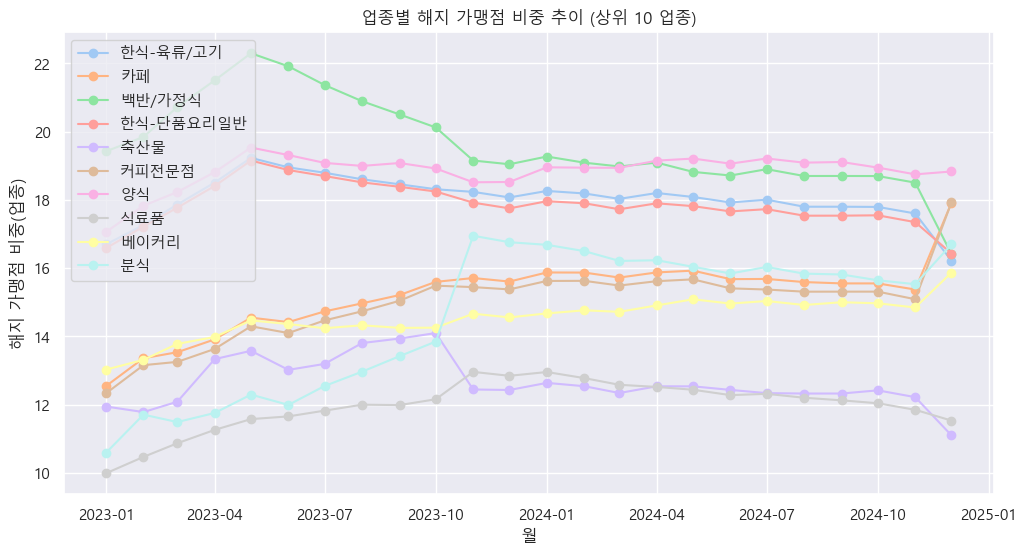

In [38]:
N = 10

cnt_by_ind = master.groupby("industry_name")["mct_id"].nunique().sort_values(ascending=False)
top_ind = cnt_by_ind.head(N).index.tolist()

trend = (
    master[master["industry_name"].isin(top_ind)]
    .groupby(["trans_date","industry_name"])["industry_close_pct"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))
for ind in top_ind:
    s = trend[trend["industry_name"]==ind]
    plt.plot(s["trans_date"], s["industry_close_pct"], marker="o", label=ind)

plt.title(f"업종별 해지 가맹점 비중 추이 (상위 {N} 업종)")
plt.xlabel("월")
plt.ylabel("해지 가맹점 비중(업종)")
plt.legend()
plt.grid(True)
plt.show()


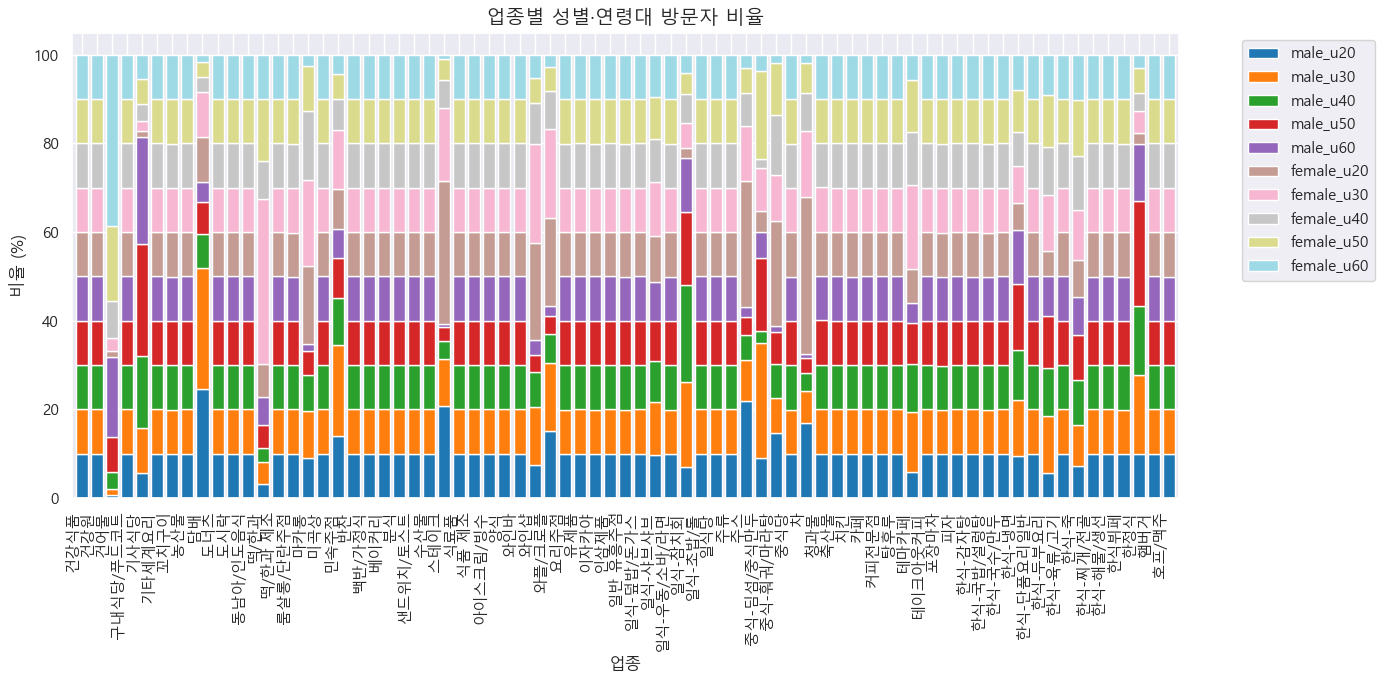

In [48]:
gender_age_cols = [
    "male_u20","male_u30","male_u40","male_u50","male_u60",
    "female_u20","female_u30","female_u40","female_u50","female_u60"
]

df_ga = master.groupby("industry_name")[gender_age_cols].mean()

df_ga_pct = df_ga.div(df_ga.sum(axis=1), axis=0) * 100

df_ga_pct.plot(kind="bar", stacked=True, figsize=(14,7),
               colormap="tab20", width=0.8)

plt.title("업종별 성별·연령대 방문자 비율", fontsize=14)
plt.ylabel("비율 (%)")
plt.xlabel("업종")
plt.xticks(rotation=90, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


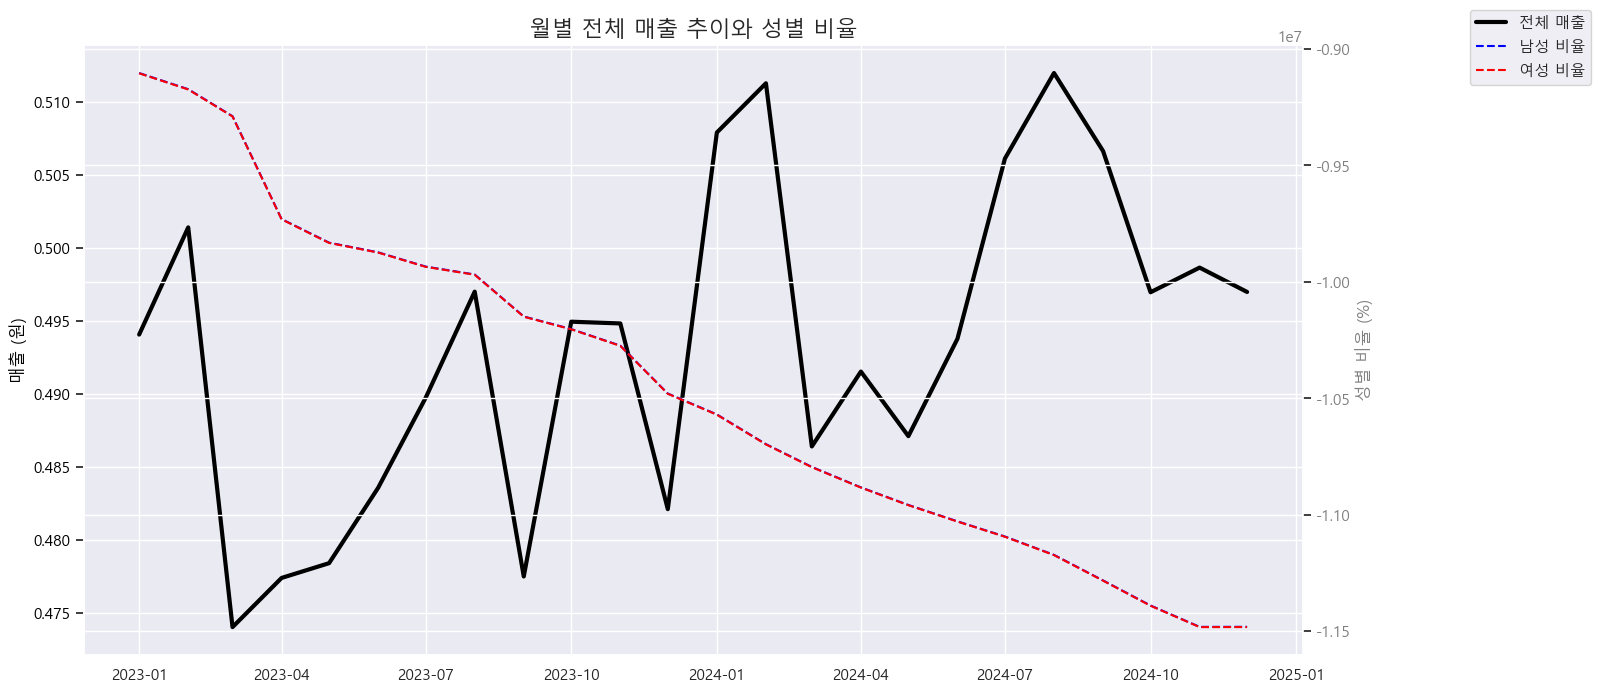

In [40]:

male_cols = ["male_u20","male_u30","male_u40","male_u50","male_u60"]
female_cols = ["female_u20","female_u30","female_u40","female_u50","female_u60"]

df = master.copy()
df["male_ratio"] = df[male_cols].sum(axis=1)
df["female_ratio"] = df[female_cols].sum(axis=1)

trend = df.groupby("trans_date")[["sale_value","male_ratio","female_ratio"]].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(14,7))

ax1.plot(trend["trans_date"], trend["sale_value"], 
         color="black", linewidth=3, label="전체 매출")
ax1.set_ylabel("매출 (원)", color="black")
ax1.tick_params(axis="y", labelcolor="black")

ax2 = ax1.twinx()
ax2.plot(trend["trans_date"], trend["male_ratio"]*100, 
         color="blue", linestyle="--", label="남성 비율")
ax2.plot(trend["trans_date"], trend["female_ratio"]*100, 
         color="red", linestyle="--", label="여성 비율")
ax2.set_ylabel("성별 비율 (%)", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")

fig.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("월별 전체 매출 추이와 성별 비율", fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


In [41]:
closed_shops = master[master["close_date"].notna()].copy()
closed_shops

,mct_id,trans_date,operation_band,sale_amt_band,sale_cnt_band,unique_customer_band,aov_band,cancel_rate_band,delivery_sale_amount_ratio,industry_sale_amt_ratio,industry_sale_cnt_ratio,industry_sale_rank_pct,area_sale_rank_pct,industry_close_pct,area_close_pct,male_u20,male_u30,male_u40,male_u50,male_u60,female_u20,female_u30,female_u40,female_u50,female_u60,visit_re,visit_new,route_resident,route_worker,route_floating,매출값,trans_month,sale_value,industry_name,commercial_area,open_date,close_date,closed_flag,close_month,months_from_close,last_month,months_from_last
39254,04393D7C92,2023-05-01,4_50-75%,4_50-75%,4_50-75%,4_50-75%,3_25-50%,6_상위6구간(하위1구간),20.9,50.1,23.3,37.7,0.0,9.5,-999999.9,10.0848,14.6256,10.2960,13.4640,4.3296,9.0152,13.0744,9.2040,12.0360,3.8704,20.19,6.73,54.5,13.6,31.8,0.625,2023-05-01,0.625,한식-육류/고기,NaN,1970-01-01 00:00:00.020190313,1970-01-01 00:00:00.020250723,1,1970-01-01,640.0,2024-12-01,-19
39255,04393D7C92,2023-05-01,4_50-75%,4_50-75%,4_50-75%,4_50-75%,3_25-50%,6_상위6구간(하위1구간),20.9,50.1,23.3,37.7,0.0,9.5,-999999.9,9.6481,15.4693,10.6183,12.9360,5.2283,8.2519,13.2307,9.0817,11.0640,4.4717,21.63,7.69,76.9,11.5,11.5,0.625,2023-05-01,0.625,한식-육류/고기,NaN,1970-01-01 00:00:00.020190313,1970-01-01 00:00:00.020250723,1,1970-01-01,640.0,2024-12-01,-19
39256,04393D7C92,2023-05-01,4_50-75%,4_50-75%,4_50-75%,4_50-75%,3_25-50%,6_상위6구간(하위1구간),20.9,50.1,23.3,37.7,0.0,9.5,-999999.9,10.8360,15.2736,10.2168,12.5388,2.7348,10.1640,14.3264,9.5832,11.7612,2.5652,18.55,5.65,50.0,20.0,30.0,0.625,2023-05-01,0.625,한식-육류/고기,NaN,1970-01-01 00:00:00.020190313,1970-01-01 00:00:00.020250723,1,1970-01-01,640.0,2024-12-01,-19
39257,04393D7C92,2023-05-01,4_50-75%,4_50-75%,4_50-75%,4_50-75%,3_25-50%,6_상위6구간(하위1구간),20.9,50.1,23.3,37.7,0.0,9.5,-999999.9,11.6852,15.9296,9.5892,12.7856,2.4104,10.6148,14.4704,8.7108,11.6144,2.1896,20.08,4.72,77.8,0.0,22.2,0.625,2023-05-01,0.625,한식-육류/고기,NaN,1970-01-01 00:00:00.020190313,1970-01-01 00:00:00.020250723,1,1970-01-01,640.0,2024-12-01,-19
39258,04393D7C92,2023-05-01,4_50-75%,4_50-75%,4_50-75%,4_50-75%,3_25-50%,6_상위6구간(하위1구간),20.9,50.1,23.3,37.7,0.0,9.5,-999999.9,11.8341,11.6393,8.4251,11.4445,5.4057,12.4659,12.2607,8.8749,12.0555,5.6943,28.75,3.13,66.7,22.2,11.1,0.625,2023-05-01,0.625,한식-육류/고기,NaN,1970-01-01 00:00:00.020190313,1970-01-01 00:00:00.020250723,1,1970-01-01,640.0,2024-12-01,-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1944162,FE30B6645E,2023-01-01,4_50-75%,3_25-50%,3_25-50%,3_25-50%,4_50-75%,1_상위1구간,75.7,106.5,201.4,14.9,24.4,14.8,8.9,18.4764,14.8780,10.9336,15.4316,9.4804,8.2236,6.6220,4.8664,6.8684,4.2196,35.34,4.81,67.0,7.3,25.7,0.375,2023-01-01,0.375,치킨,왕십리,1970-01-01 00:00:00.020190124,1970-01-01 00:00:00.020230321,1,1970-01-01,636.0,2023-03-01,-2
1944163,FE30B6645E,2023-01-01,4_50-75%,3_25-50%,3_25-50%,3_25-50%,4_50-75%,1_상위1구간,75.7,106.5,201.4,14.9,24.4,14.8,8.9,18.5504,14.0492,10.9802,15.4814,9.0706,8.6496,6.5508,5.1198,7.2186,4.2294,34.02,4.57,65.8,7.0,27.2,0.375,2023-01-01,0.375,치킨,왕십리,1970-01-01 00:00:00.020190124,1970-01-01 00:00:00.020230321,1,1970-01-01,636.0,2023-03-01,-2
1944164,FE30B6645E,2023-03-01,6_90%초과(하위 10% 이하),4_50-75%,3_25-50%,3_25-50%,4_50-75%,4_상위4구간,78.5,75.6,148.8,15.4,24.5,15.9,9.4,18.6300,14.2830,11.1090,15.3180,9.5910,8.3700,6.4170,4.9910,6.8820,4.3090,35.26,6.20,63.1,6.2,30.8,0.625,2023-03-01,0.625,치킨,왕십리,1970-01-01 00:00:00.020190124,1970-01-01 00:00:00.020230321,1,1970-01-01,638.0,2023-03-01,0
1944165,FE30B6645E,2023-03-01,6_90%초과(하위 10% 이하),4_50-75%,3_25-50%,3_25-50%,4_50-75%,4_상위4구간,78.5,75.6,148.8,15.4,24.5,15.9,9.4,18.4764,14.8780,10.9336,15.4316,9.4804,8.2236,6.6220,4.8664,6.8684,4.2196,35.34,4.81,67.0,7.3,25.7,0.625,2023-03-01,0.625,치킨,왕십리,1970-01-01 00:00:00.020190124,1970-01-01 00:00:00.020230321,1,1970-01-01,638.0,2023-03-01,0


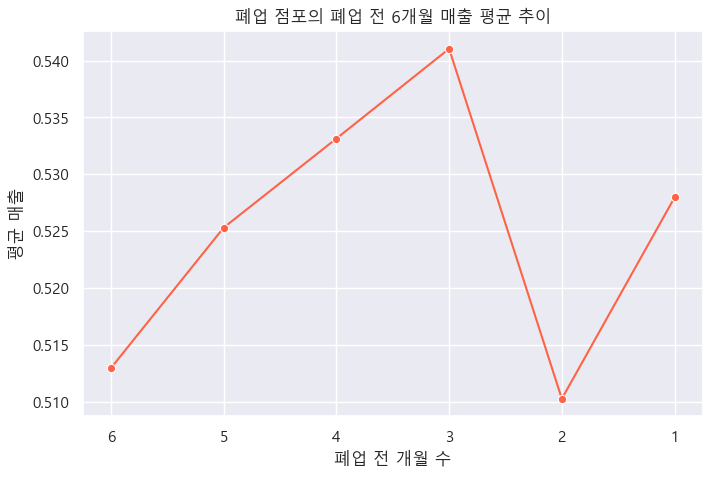

In [42]:
closed_shops = master[master["close_date"].notna()].copy()

closed_month = closed_shops.groupby("mct_id")["trans_date"].max().reset_index()
closed_month.columns = ["mct_id", "closed_month"]

closed_shops = closed_shops.merge(closed_month, on="mct_id", how="left")

closed_shops["month_dif"] = (
    closed_shops["closed_month"].dt.to_period("M").view(int) 
    - closed_shops["trans_date"].dt.to_period("M").view(int)
)
last_6mon = closed_shops[
    (closed_shops["month_dif"] > 0) & (closed_shops["month_dif"] <= 6)
]

avg_sales_by_month = last_6mon.groupby("month_dif")["매출값"].mean().reset_index()

# 6. 시각화 (x=개월, y=평균매출)
plt.figure(figsize=(8,5))
sns.lineplot(data=avg_sales_by_month, x="month_dif", y="매출값", marker="o", color="tomato")
plt.title("폐업 점포의 폐업 전 6개월 매출 평균 추이")
plt.xlabel("폐업 전 개월 수")
plt.ylabel("평균 매출")
plt.gca().invert_xaxis()  
plt.grid(True)
plt.show()


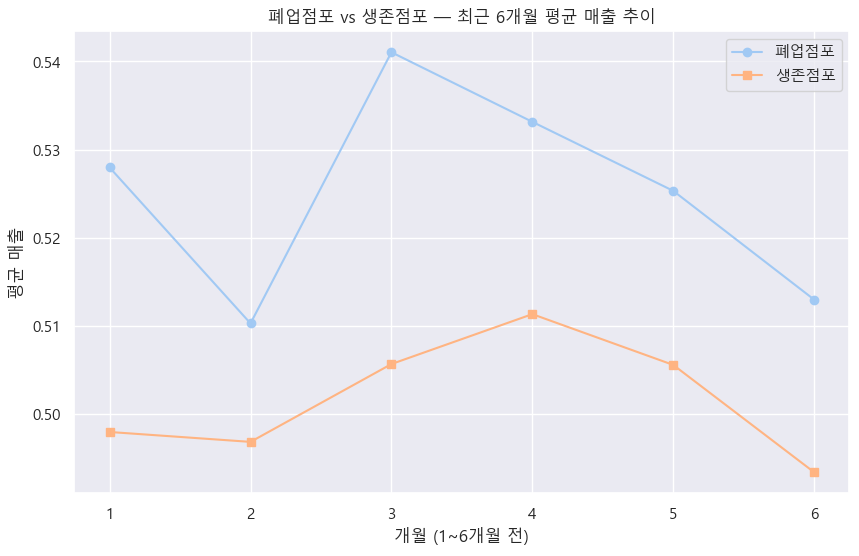

In [43]:

master = master.copy()
master["trans_idx"] = master["trans_date"].dt.year * 12 + master["trans_date"].dt.month

closed = master[master["close_date"].notna()].copy()

closed_month = closed.groupby("mct_id")["trans_date"].max().reset_index()
closed_month.columns = ["mct_id", "closed_month"]
closed = closed.merge(closed_month, on="mct_id", how="left")

closed["closed_idx"] = closed["closed_month"].dt.year * 12 + closed["closed_month"].dt.month
closed["month_dif"] = closed["closed_idx"] - closed["trans_idx"]
closed_last6 = closed[(closed["month_dif"] >= 1) & (closed["month_dif"] <= 6)]

closed_trend = (
    closed_last6.groupby("month_dif")["매출값"].mean()
    .reindex(range(1,7))   # x축 1~6 고정
)

survived = master[master["close_date"].isna()].copy()
last_month = survived["trans_date"].max()
base_idx = last_month.year * 12 + last_month.month

survived["month_dif"] = base_idx - survived["trans_idx"]
survived_last6 = survived[(survived["month_dif"] >= 1) & (survived["month_dif"] <= 6)]

survived_trend = (
    survived_last6.groupby("month_dif")["매출값"].mean()
    .reindex(range(1,7)) 
)

x = range(1,7)
plt.figure(figsize=(10,6))
plt.plot(x, closed_trend.values, marker="o", label="폐업점포")
plt.plot(x, survived_trend.values, marker="s", label="생존점포")

plt.title("폐업점포 vs 생존점포 — 최근 6개월 평균 매출 추이")
plt.xlabel("개월 (1~6개월 전)")
plt.ylabel("평균 매출")
plt.grid(True)
plt.legend()
plt.show()


           구분    매출비율(%)
0    male_u20  10.000025
1    male_u30   9.999308
2    male_u40   9.999905
3    male_u50   9.999460
4    male_u60   9.999849
5  female_u20  10.000190
6  female_u30   9.999820
7  female_u40  10.000556
8  female_u50  10.000379
9  female_u60  10.000509


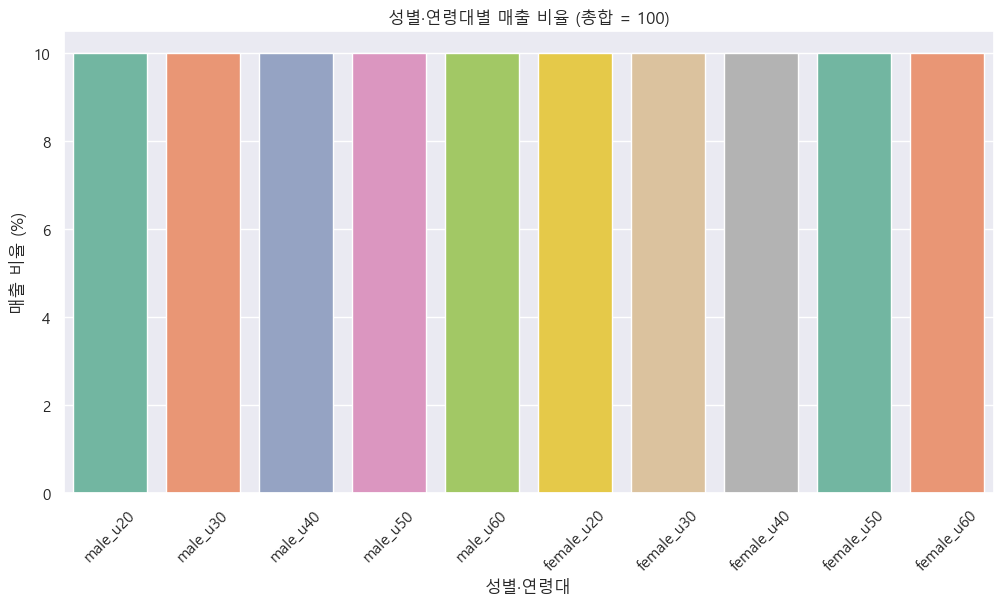

In [50]:
gender_age_cols = [
    "male_u20", "male_u30", "male_u40", "male_u50", "male_u60",
    "female_u20", "female_u30", "female_u40", "female_u50", "female_u60"
]

for col in gender_age_cols:
    master[col + "_amt"] = master["매출값"] * master[col]

gender_age_totals = master[[c + "_amt" for c in gender_age_cols]].sum()
total_sales = gender_age_totals.sum()


gender_age_ratio = (gender_age_totals / total_sales) * 100
gender_age_ratio = gender_age_ratio.reset_index()
gender_age_ratio.columns = ["구분", "매출비율(%)"]

# 구분 컬럼을 보기 좋게 정리
gender_age_ratio["구분"] = gender_age_ratio["구분"].str.replace("_amt","")

print(gender_age_ratio)


plt.figure(figsize=(12,6))
sns.barplot(data=gender_age_ratio, x="구분", y="매출비율(%)", palette="Set2")
plt.title("성별·연령대별 매출 비율 (총합 = 100)")
plt.xticks(rotation=45)
plt.ylabel("매출 비율 (%)")
plt.xlabel("성별·연령대")
plt.show()


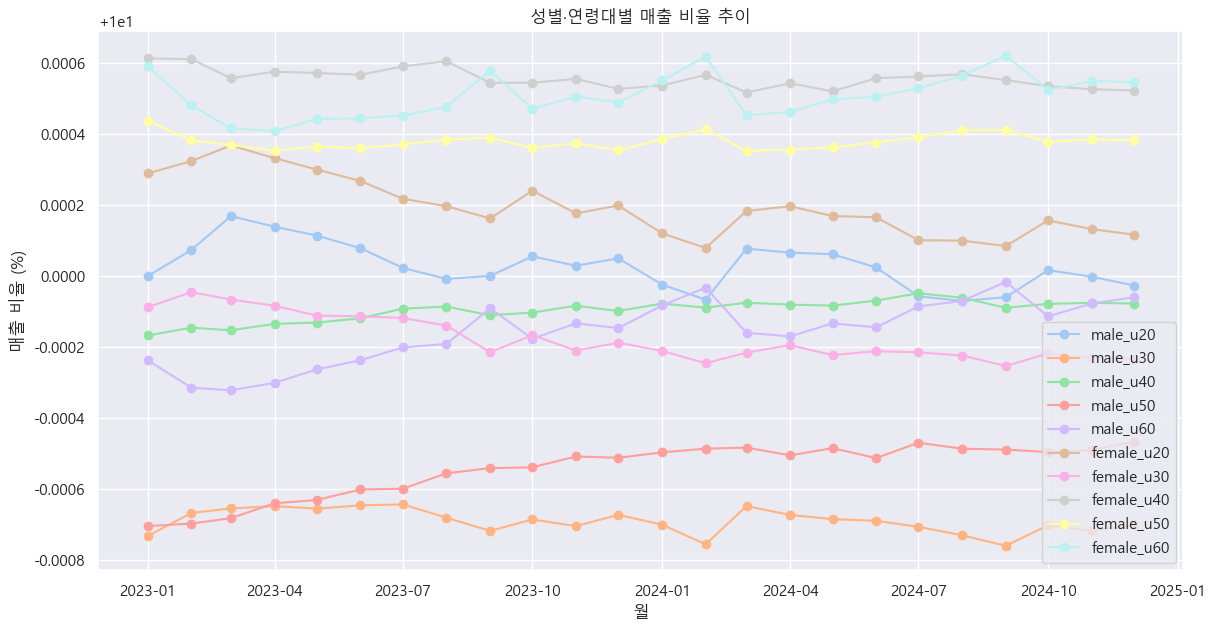

In [51]:

trend = master.groupby("trans_month")[
    [c + "_amt" for c in gender_age_cols]
].sum()

trend = trend.div(trend.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14,7))
for col in trend.columns:
    plt.plot(trend.index, trend[col], marker="o", label=col.replace("_amt",""))

plt.title("성별·연령대별 매출 비율 추이")
plt.xlabel("월")
plt.ylabel("매출 비율 (%)")
plt.legend()
plt.grid(True)
plt.show()


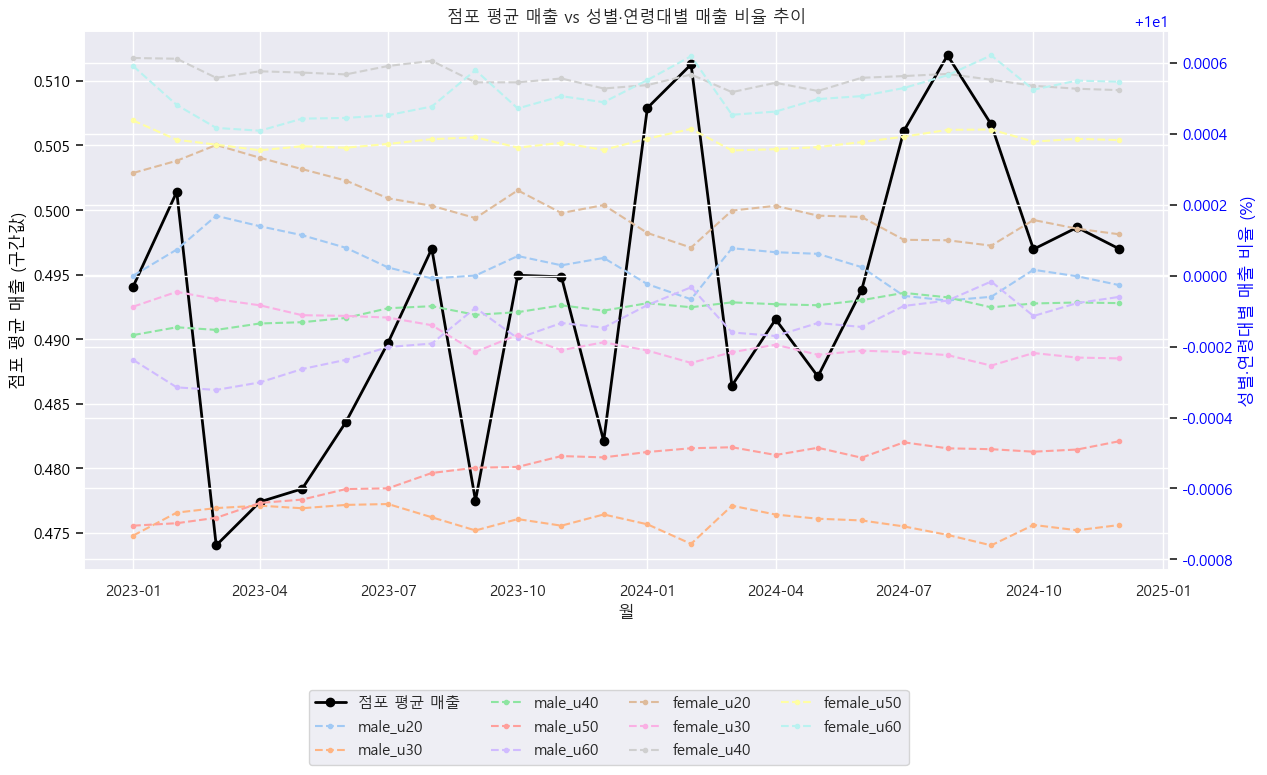

In [52]:
# 1️⃣ 월별 점포 평균 매출 계산
sales_sum = master.groupby(master["trans_month"].dt.to_period("M"))["매출값"].sum()
sales_cnt = master.groupby(master["trans_month"].dt.to_period("M"))["매출값"].count()
sales = (sales_sum / sales_cnt).to_timestamp().to_frame(name="점포평균매출")

# 2️⃣ 월별 성별·연령대별 매출액 합계 → 비율 계산
trend = master.groupby(master["trans_month"].dt.to_period("M"))[
    [c + "_amt" for c in gender_age_cols]
].sum()
trend = trend.div(trend.sum(axis=1), axis=0) * 100
trend.index = trend.index.to_timestamp()

# 3️⃣ 시각화 (이중 y축)
fig, ax1 = plt.subplots(figsize=(14,7))

# --- 왼쪽 y축: 점포 평균 매출
ax1.plot(sales.index, sales["점포평균매출"], color="black", linewidth=2, marker="o", label="점포 평균 매출")
ax1.set_xlabel("월")
ax1.set_ylabel("점포 평균 매출 (구간값)", color="black")
ax1.tick_params(axis="y", labelcolor="black")

# --- 오른쪽 y축: 성별·연령대별 매출 비율
ax2 = ax1.twinx()
for col in trend.columns:
    ax2.plot(trend.index, trend[col], marker=".", linestyle="--", label=col.replace("_amt",""))

ax2.set_ylabel("성별·연령대별 매출 비율 (%)", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

# --- 범례
fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=4)
plt.title("점포 평균 매출 vs 성별·연령대별 매출 비율 추이")
plt.grid(True)
plt.show()


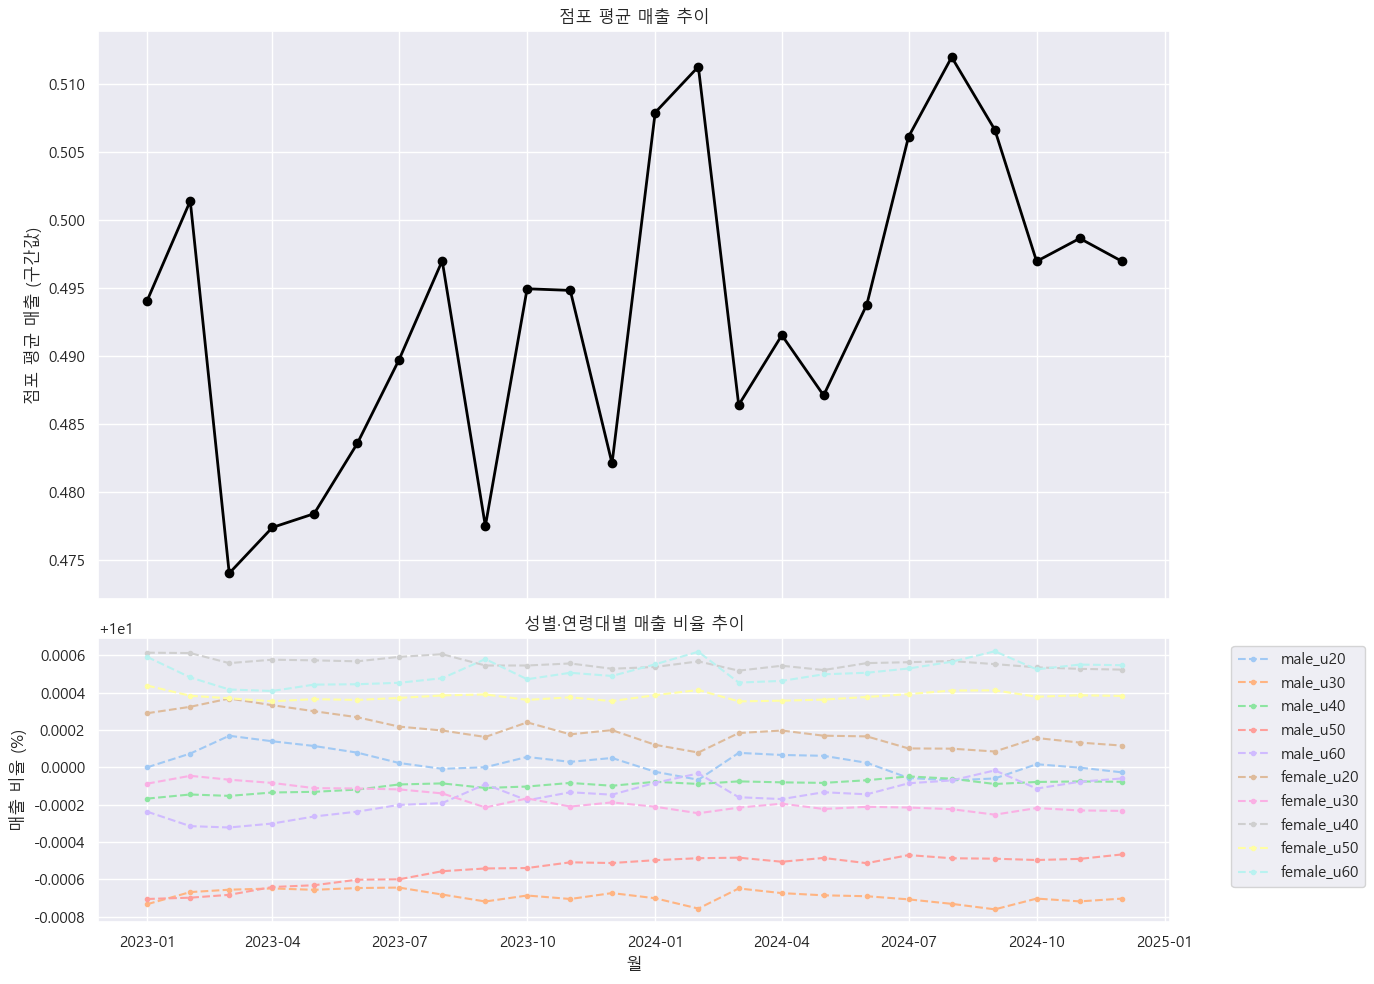

In [53]:
# 1️⃣ 월별 점포 평균 매출
sales_sum = master.groupby(master["trans_month"].dt.to_period("M"))["매출값"].sum()
sales_cnt = master.groupby(master["trans_month"].dt.to_period("M"))["매출값"].count()
sales = (sales_sum / sales_cnt).to_timestamp().to_frame(name="점포평균매출")

# 2️⃣ 월별 성별·연령대별 매출 비율 (%)
trend = master.groupby(master["trans_month"].dt.to_period("M"))[
    [c + "_amt" for c in gender_age_cols]
].sum()
trend = trend.div(trend.sum(axis=1), axis=0) * 100
trend.index = trend.index.to_timestamp()

# 3️⃣ 시각화 (2단 서브플롯)
fig, axes = plt.subplots(2, 1, figsize=(14,10), sharex=True, gridspec_kw={'height_ratios':[2,1]})

# (위) 점포 평균 매출
axes[0].plot(sales.index, sales["점포평균매출"], color="black", linewidth=2, marker="o")
axes[0].set_title("점포 평균 매출 추이")
axes[0].set_ylabel("점포 평균 매출 (구간값)")
axes[0].grid(True)

# (아래) 성별·연령대별 매출 비율
for col in trend.columns:
    axes[1].plot(trend.index, trend[col], marker=".", linestyle="--", label=col.replace("_amt",""))
axes[1].set_title("성별·연령대별 매출 비율 추이")
axes[1].set_ylabel("매출 비율 (%)")
axes[1].set_xlabel("월")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [56]:
merged_df['cancel_rate_band'].unique()

array(['1_상위1구간', nan, '6_상위6구간(하위1구간)', '5_상위5구간', '3_상위3구간', '2_상위2구간',
       '4_상위4구간'], dtype=object)

In [59]:
merged_df['delivery_sale_amount_ratio']


0         -999999.9
1         -999999.9
2         -999999.9
3         -999999.9
4         -999999.9
             ...   
1960285   -999999.9
1960286   -999999.9
1960287   -999999.9
1960288   -999999.9
1960289   -999999.9
Name: delivery_sale_amount_ratio, Length: 1960290, dtype: float64